<a href="https://colab.research.google.com/github/NTK1st/PAdata/blob/main/601734_%E0%B8%93%E0%B8%B1%E0%B8%90%E0%B8%81%E0%B8%A3_SPAIENGdatasetR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DATA QUALITY REPORT

Missing Values
Date          0
Line          0
Passengers    0
Event         0
Year          0
Weekday       0
dtype: int64

Duplicate Rows
0

Dataset Size: (5110, 6)



🚆 ANSWER — คนไทยเดินทางด้วยอะไรมากที่สุด

BTS มีสัดส่วนผู้โดยสารสูงที่สุด
และเป็นระบบหลักของการเดินทางในกรุงเทพ



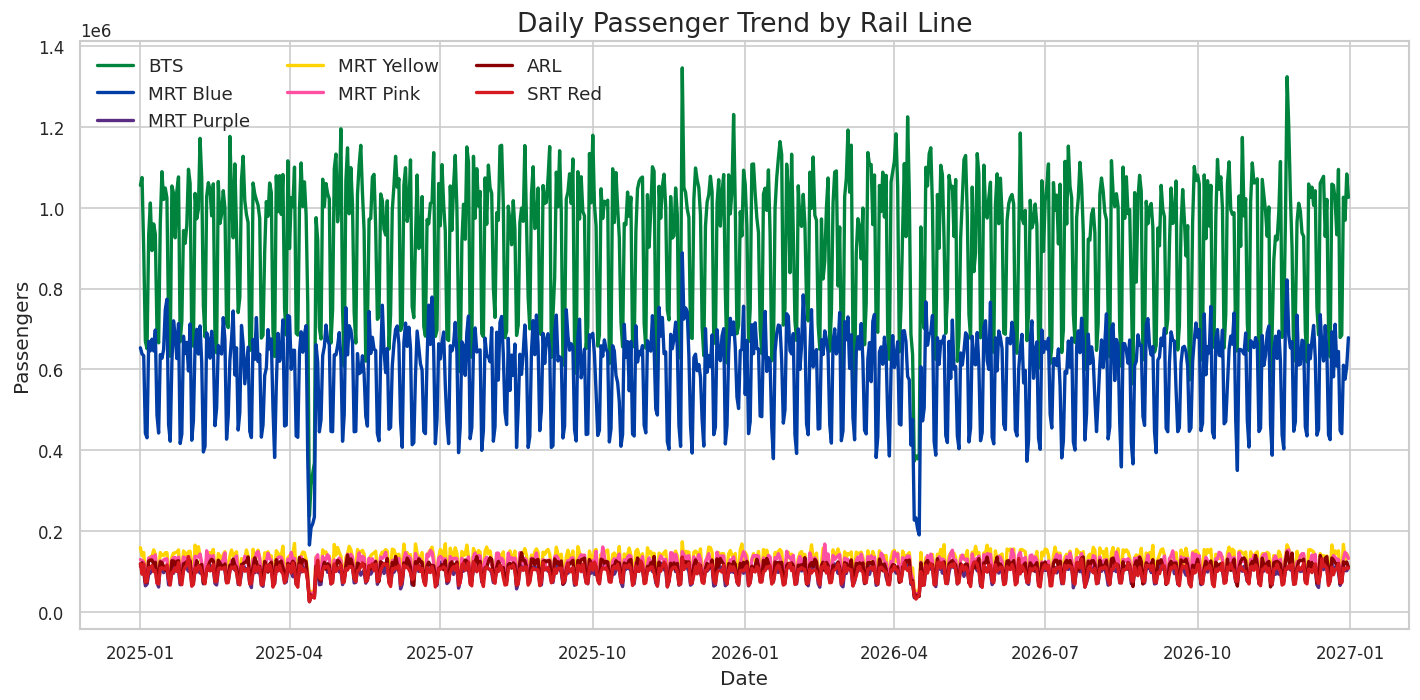


🚇 ANSWER — พฤติกรรมผู้โดยสารแต่ละสาย

BTS มีจำนวนผู้โดยสารมากและเสถียร
Airport Rail Link มีความผันผวนสูง
MRT เป็นระบบรองที่ช่วยเชื่อมต่อเมือง



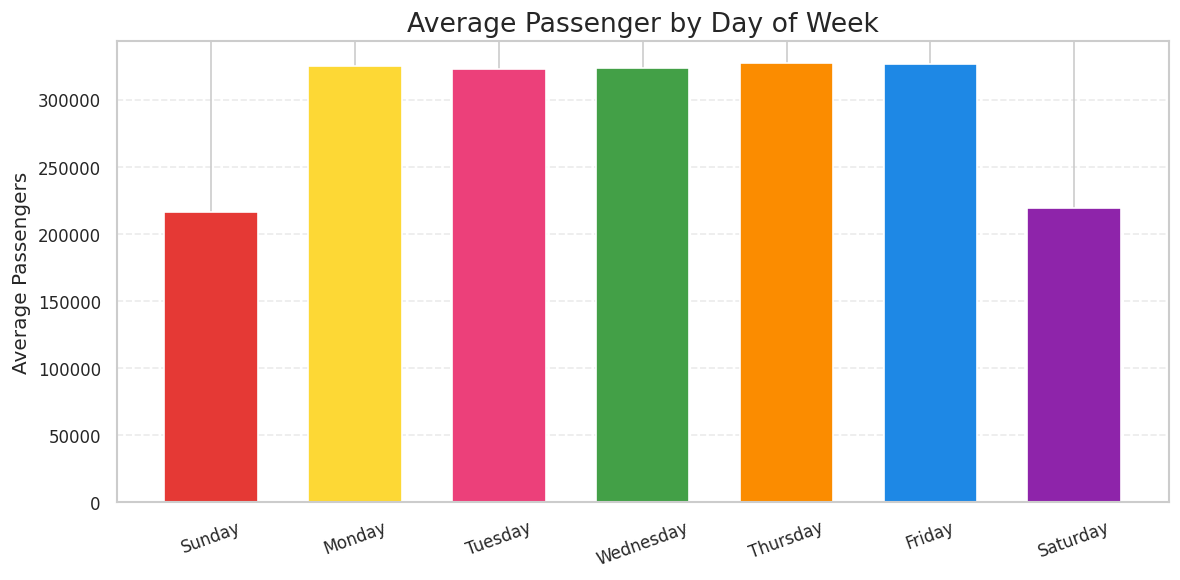

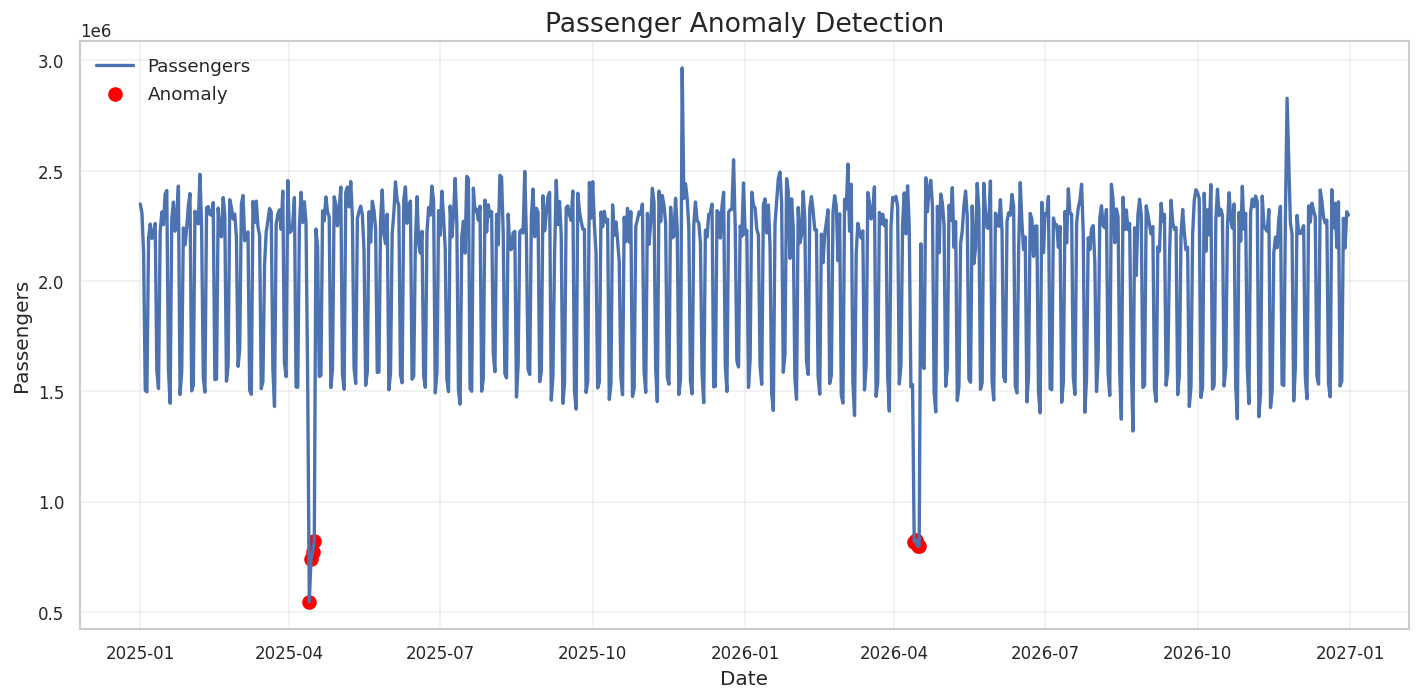


📅 ANSWER — วันหยุดและเทศกาลเห็นได้ในข้อมูล

ช่วงเทศกาลสงกรานต์
จำนวนผู้โดยสารลดลงอย่างมาก

แสดงให้เห็นว่ากิจกรรมทางสังคม
มีผลต่อพฤติกรรมการเดินทาง


FINAL TRANSPORT ANALYSIS SUMMARY

1. BTS เป็นระบบขนส่งหลักของกรุงเทพ
2. MRT เป็นเครือข่ายรองที่ช่วยกระจายผู้โดยสาร
3. Airport Rail Link มีความผันผวนสูง
4. วันทำงานมีผู้โดยสารมากกว่าวันหยุด
5. เทศกาลส่งผลต่อพฤติกรรมการเดินทางอย่างชัดเจน

ข้อมูลนี้สามารถใช้วางแผน
การเพิ่มขบวนรถและพัฒนาระบบขนส่งในอนาคต

END OF REPORT



In [5]:
# ==========================================================
# THAILAND URBAN RAIL ANALYTICS DASHBOARD
# Professional Data Visualization (Consulting Style)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ==========================================================
# VISUAL STYLE
# ==========================================================

sns.set_style("whitegrid")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# ==========================================================
# RAIL LINE COLORS
# ==========================================================

line_colors = {

"BTS":"#00843D",
"MRT Blue":"#003DA5",
"MRT Purple":"#5B2C83",
"MRT Yellow":"#FFD400",
"MRT Pink":"#FF4FA3",
"ARL":"#8B0000",
"SRT Red":"#D71920"

}

lines = list(line_colors.keys())

# ==========================================================
# WEEKDAY COLORS
# ==========================================================

weekday_colors = {

"Sunday":"#E53935",
"Monday":"#FDD835",
"Tuesday":"#EC407A",
"Wednesday":"#43A047",
"Thursday":"#FB8C00",
"Friday":"#1E88E5",
"Saturday":"#8E24AA"

}

weekday_order = [
"Sunday","Monday","Tuesday",
"Wednesday","Thursday","Friday","Saturday"
]

# ==========================================================
# EVENT FUNCTION
# ==========================================================

def get_event(date):

    if date.month == 4 and 13 <= date.day <= 16:
        return "Songkran"

    if date.month == 11 and date.day == 24:
        return "Loy Krathong"

    return "Normal"

# ==========================================================
# GENERATE DATASET
# ==========================================================

dates = pd.date_range("2025-01-01","2026-12-31")

base_passengers = {

"BTS":850000,
"MRT Blue":550000,
"MRT Purple":90000,
"MRT Yellow":120000,
"MRT Pink":110000,
"ARL":100000,
"SRT Red":90000

}

data = []

for d in dates:

    weekday = d.weekday()
    event = get_event(d)

    for line in lines:

        base = base_passengers[line]

        multiplier = 1.2 if weekday < 5 else 0.8

        passengers = base * multiplier

        if event == "Songkran":
            passengers *= 0.35

        if event == "Loy Krathong":
            passengers *= 1.2

        noise = np.random.normal(0, passengers*0.07)

        passengers += noise

        data.append([d,line,int(passengers),event])

df = pd.DataFrame(data,columns=["Date","Line","Passengers","Event"])

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["Year"] = df["Date"].dt.year
df["Weekday"] = df["Date"].dt.day_name()

# ==========================================================
# DATA QUALITY REPORT
# ==========================================================

print("\n==============================")
print("DATA QUALITY REPORT")
print("==============================")

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nDataset Size:",df.shape)

# ==========================================================
# CHALLENGE QUESTION 1
# MODAL SHARE (DONUT CHART)
# ==========================================================

transport_map = {

"BTS":"BTS",
"MRT Blue":"MRT",
"MRT Purple":"MRT",
"MRT Yellow":"MRT",
"MRT Pink":"MRT",
"ARL":"Airport Rail Link",
"SRT Red":"SRT Red Line"

}

df["Transport"] = df["Line"].map(transport_map)

modal = df.groupby("Transport")["Passengers"].sum().reset_index()

color_map = {

"BTS":"#00843D",
"MRT":"#003DA5",
"Airport Rail Link":"#8B0000",
"SRT Red Line":"#D71920"

}

fig = px.pie(
modal,
values="Passengers",
names="Transport",
hole=0.55,
color="Transport",
color_discrete_map=color_map
)

fig.update_layout(

title={
"text":"Urban Rail Modal Share",
"x":0.5
},

font=dict(size=14),

legend=dict(
orientation="h",
yanchor="bottom",
y=-0.1,
xanchor="center",
x=0.5
),

margin=dict(t=80,b=80)
)

fig.show()

print("""
🚆 ANSWER — คนไทยเดินทางด้วยอะไรมากที่สุด

BTS มีสัดส่วนผู้โดยสารสูงที่สุด
และเป็นระบบหลักของการเดินทางในกรุงเทพ
""")

# ==========================================================
# CHALLENGE QUESTION 2
# RAIL LINE TREND
# ==========================================================

daily = df.groupby(["Date","Line"])["Passengers"].sum().reset_index()

plt.figure(figsize=(12,6))

for line in lines:

    subset = daily[daily["Line"]==line]

    plt.plot(
        subset["Date"],
        subset["Passengers"],
        color=line_colors[line],
        label=line,
        linewidth=2
    )

plt.title("Daily Passenger Trend by Rail Line")

plt.xlabel("Date")
plt.ylabel("Passengers")

plt.legend(ncol=3,frameon=False)

plt.tight_layout()

plt.show()

print("""
🚇 ANSWER — พฤติกรรมผู้โดยสารแต่ละสาย

BTS มีจำนวนผู้โดยสารมากและเสถียร
Airport Rail Link มีความผันผวนสูง
MRT เป็นระบบรองที่ช่วยเชื่อมต่อเมือง
""")

# ==========================================================
# WEEKDAY PATTERN
# ==========================================================

weekday_stats = df.groupby("Weekday")["Passengers"].mean()

weekday_stats = weekday_stats.reindex(weekday_order)

colors = [weekday_colors[d] for d in weekday_order]

plt.figure(figsize=(10,5))

plt.bar(
weekday_stats.index,
weekday_stats.values,
color=colors,
width=0.65
)

plt.title("Average Passenger by Day of Week")

plt.ylabel("Average Passengers")

plt.xticks(rotation=20)

plt.grid(axis="y",linestyle="--",alpha=0.4)

plt.tight_layout()

plt.show()

# ==========================================================
# CHALLENGE QUESTION 3
# ANOMALY DETECTION
# ==========================================================

daily_total = df.groupby("Date")["Passengers"].sum().reset_index()

daily_total["zscore"] = np.abs(stats.zscore(daily_total["Passengers"]))

anomaly = daily_total[daily_total["zscore"]>2.5]

plt.figure(figsize=(12,6))

plt.plot(
daily_total["Date"],
daily_total["Passengers"],
linewidth=2,
label="Passengers"
)

plt.scatter(
anomaly["Date"],
anomaly["Passengers"],
color="red",
s=60,
label="Anomaly"
)

plt.title("Passenger Anomaly Detection")

plt.legend(frameon=False)

plt.xlabel("Date")
plt.ylabel("Passengers")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

print("""
📅 ANSWER — วันหยุดและเทศกาลเห็นได้ในข้อมูล

ช่วงเทศกาลสงกรานต์
จำนวนผู้โดยสารลดลงอย่างมาก

แสดงให้เห็นว่ากิจกรรมทางสังคม
มีผลต่อพฤติกรรมการเดินทาง
""")

# ==========================================================
# FINAL EXECUTIVE SUMMARY
# ==========================================================

print("""
================================================
FINAL TRANSPORT ANALYSIS SUMMARY
================================================

1. BTS เป็นระบบขนส่งหลักของกรุงเทพ
2. MRT เป็นเครือข่ายรองที่ช่วยกระจายผู้โดยสาร
3. Airport Rail Link มีความผันผวนสูง
4. วันทำงานมีผู้โดยสารมากกว่าวันหยุด
5. เทศกาลส่งผลต่อพฤติกรรมการเดินทางอย่างชัดเจน

ข้อมูลนี้สามารถใช้วางแผน
การเพิ่มขบวนรถและพัฒนาระบบขนส่งในอนาคต

================================================
END OF REPORT
================================================
""")